# Preferential choice data analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import json
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from modules import *

plt.rcParams['font.size'] = 14
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['font.family'] = 'Arial'

In [2]:
# set random seed
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

## Load data

In [3]:
data_raw = pd.read_csv('data/krajbich_PNAS_2011/data.csv')
data_raw.head()

,Unnamed: 0,trial,rating1,rating2,rating3,roirating,rt,chosenrating,subject,eventduration,fix_num,choice1,choice2,choice3,leftroi,middleroi,rightroi,num_fixations,rev_fix_num
0,1,1,1,7,3,7,1782,7,1,318,1,0,1,0,0,1,0,4,4
1,2,1,1,7,3,3,1782,7,1,160,2,0,1,0,0,0,1,4,3
2,3,1,1,7,3,1,1782,7,1,139,3,0,1,0,1,0,0,4,2
3,4,1,1,7,3,7,1782,7,1,818,4,0,1,0,0,1,0,4,1
4,5,2,7,3,2,3,1063,3,1,119,1,0,1,0,0,1,0,4,4


## Preprocessing

In [4]:
from itertools import groupby

data = []

for pid in data_raw['subject'].unique():
    # create recording
    data_subj = {
        'pids': [],
        'values': [],
        'fixation_seqs': [],
        'decisions': [],
        'duration_seqs': [],
        'total_durations': [],
    }

    # filter out subject data
    data_raw_subj = data_raw[data_raw['subject'] == pid]

    for tid in data_raw_subj['trial'].unique():
        # filter out trial data
        data_raw_trial = data_raw_subj[data_raw_subj['trial'] == tid]
        
        # get values
        values_ep = list(data_raw_trial.iloc[0][['rating1', 'rating2', 'rating3']])

        # get fixation sequence
        fixation_seq_ep = list(np.argmax(data_raw_trial[['leftroi', 'middleroi', 'rightroi']], axis = 1))

        # get decision
        decision_ep = np.argmax(data_raw_trial[['choice1', 'choice2', 'choice3']].iloc[0]) # 0 for left, 1 for right

        # get duration sequence
        duration_seq_ep = list(data_raw_trial['eventduration'])

        # get total fixation time
        total_duration_ep = sum(duration_seq_ep)

        # append data
        data_subj['pids'].append(int(pid))
        data_subj['values'].append(values_ep)
        data_subj['fixation_seqs'].append(fixation_seq_ep)
        data_subj['decisions'].append(decision_ep)
        data_subj['duration_seqs'].append(duration_seq_ep)
        data_subj['total_durations'].append(total_duration_ep)
    
    data.append(data_subj)

## Choosing left vs. left-right/left-mean other rating difference (Fig 3A)

In [5]:
dfs = []

for pid, data_subj in enumerate(data):

    value_differences_subj = []
    if_left_chosens_subj = []

    for i in range(len(data_subj['pids'])):
        values_ep = data_subj['values'][i]
        decision_ep = data_subj['decisions'][i]
    
        value_differences_subj.append(values_ep[0] - np.mean(values_ep[1:]))
        if_left_chosens_subj.append(int(decision_ep == 0))
    
    df_subj = pd.DataFrame({
        'value_differences': value_differences_subj,
        'if_left_chosens': if_left_chosens_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

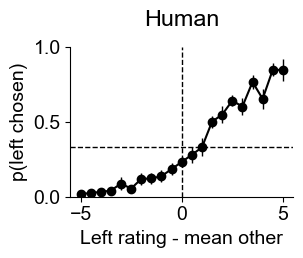

In [6]:
plt.figure(figsize = (3.25, 2.8))
df_filtered = df[(df['value_differences'] >= -5) & (df['value_differences'] <= 5)]
df_grouped = df_filtered.groupby(['pid', 'value_differences'])['if_left_chosens'].mean().reset_index()
df_summary = df_grouped.groupby(['value_differences'])['if_left_chosens'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['value_differences'], df_summary['mean'], yerr = df_summary['se'], fmt = '-o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
plt.axvline(x = 0, color = 'k', linestyle = '--', linewidth = 1)
plt.axhline(y = 1 / 3, color = 'k', linestyle = '--', linewidth = 1)
plt.xticks(range(-5, 6, 5))
plt.ylim((0, 1))
plt.xlabel('Left rating - mean other')
plt.ylabel('p(left chosen)')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_choice_by_rating_difference.pdf', bbox_inches = 'tight')

## Distribution of fixation duration (Fig 3B)

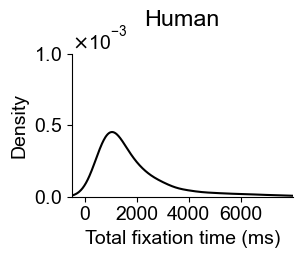

In [7]:
import matplotlib.ticker as ticker

nested = [_['total_durations'] for _ in data]
total_durations = [item for sublist in nested for item in sublist]

plt.figure(figsize = (3.25, 2.8))
sns.kdeplot(total_durations, bw_adjust = 1, gridsize = 1000, color = 'black')
plt.xticks([0, 2000, 4000, 6000])
plt.xlim(-500, 8000)
plt.ylim(0, 0.001)
plt.xlabel('Total fixation time (ms)')
plt.ylabel('Density')
plt.title('Human', pad = 20)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
ax.ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0)) # force scientific notation
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_duration_distribution.pdf.pdf', bbox_inches = 'tight')

## Fixation duration vs. best-worst/best-mean other rating difference (Fig 3C)

In [8]:
dfs = []

for pid, data_subj in enumerate(data):

    value_differences_subj = []
    total_durations_subj = []

    for i in range(len(data_subj['pids'])):
        values_ep = data_subj['values'][i]
        total_duration_ep = data_subj['total_durations'][i]
    
        value_differences_subj.append(np.max(values_ep) - np.mean(np.delete(values_ep, np.argmax(values_ep))))
        total_durations_subj.append(total_duration_ep)
    
    df_subj = pd.DataFrame({
        'value_differences': value_differences_subj,
        'total_durations': total_durations_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

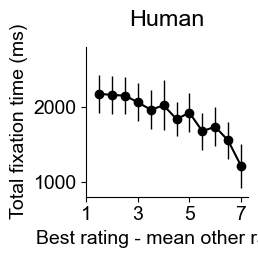

In [9]:
plt.figure(figsize = (2.8, 2.8))
df_filtered = df[df['value_differences'] <= 7]
df_grouped = df_filtered.groupby(['pid', 'value_differences'])['total_durations'].mean().reset_index()
df_summary = df_grouped.groupby(['value_differences'])['total_durations'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['value_differences'], df_summary['mean'], yerr = df_summary['se'], fmt = '-o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
plt.xticks(range(1, 8, 2))
plt.ylim((800, 2800))
plt.xlabel('Best rating - mean other rating')
plt.ylabel('Total fixation time (ms)')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_duration_by_rating_difference.pdf', bbox_inches = 'tight')

## Fixaion duration vs. rating mean (Fig 3D)

In [10]:
dfs = []

for pid, data_subj in enumerate(data):

    value_means_subj = []
    total_durations_subj = []

    for i in range(len(data_subj['pids'])):
        values_ep = data_subj['values'][i]
        total_duration_ep = data_subj['total_durations'][i]
    
        value_means_subj.append(np.mean(values_ep))
        total_durations_subj.append(total_duration_ep)
    
    df_subj = pd.DataFrame({
        'value_means': value_means_subj,
        'total_durations': total_durations_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

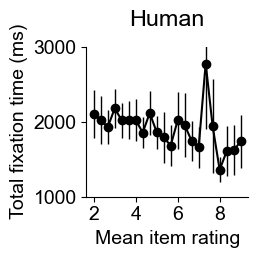

In [ ]:
plt.figure(figsize = (2.8, 2.8))
df['group'] = df['value_means']
df_grouped = df.groupby(['pid', 'group'])['total_durations'].mean().reset_index()
df_summary = df_grouped.groupby(['group'])['total_durations'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['group'], df_summary['mean'], yerr = df_summary['se'], fmt = '-o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
plt.xticks(range(2, 10, 2))
plt.ylim((1000, 3000))
plt.xlabel('Mean item rating')
plt.ylabel('Total fixation time (ms)')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_duration_by_rating_mean.pdf', bbox_inches = 'tight')

## Distribution of fixation numbers (Fig 4A)

In [12]:
fixation_counts = []

for pid, data_subj in enumerate(data):

    fixation_counts_subj = []

    for i in range(len(data_subj['pids'])):

        fixation_seq_ep = data_subj['fixation_seqs'][i]
        fixation_counts_subj.append(len(fixation_seq_ep))

    fixation_counts.append(fixation_counts_subj)

# join into one list
fixation_counts = [item for sublist in fixation_counts for item in sublist]

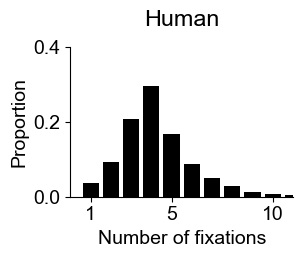

In [13]:
uniques, counts = np.unique(fixation_counts, return_counts = True)
proportions = counts / counts.sum()

plt.figure(figsize = (3.25, 2.8))
plt.bar(x = uniques, height = proportions, color = 'k')
plt.xticks([1, 5, 10])
plt.xlim(0, 11)
plt.ylim((0, 0.4))
plt.xlabel('Number of fixations')
plt.ylabel('Proportion')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_fixation_num_distribution.pdf', bbox_inches = 'tight')

## Fixation number vs. best-worst/best-mean other rating difference (Fig 4B)

In [14]:
dfs = []

for pid, data_subj in enumerate(data):

    value_differences_subj = []
    fixation_counts_subj = []

    for i in range(len(data_subj['pids'])):
        values_ep = data_subj['values'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]
    
        value_differences_subj.append(np.max(values_ep) - np.mean(np.delete(values_ep, np.argmax(values_ep))))
        fixation_counts_subj.append(len(fixation_seq_ep))
    
    df_subj = pd.DataFrame({
        'value_differences': value_differences_subj,
        'fixation_counts': fixation_counts_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

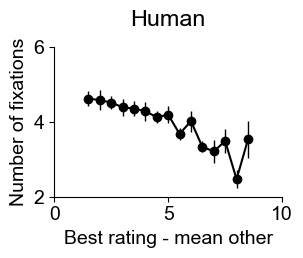

In [ ]:
plt.figure(figsize = (3.25, 2.8))
df_filtered = df
df_grouped = df_filtered.groupby(['pid', 'value_differences'])['fixation_counts'].mean().reset_index()
df_summary = df_grouped.groupby(['value_differences'])['fixation_counts'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['value_differences'], df_summary['mean'], yerr = df_summary['se'], fmt = '-o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
plt.xticks([0, 5, 10])
plt.ylim((2, 6))
plt.xlabel('Best rating - mean other')
plt.ylabel('Number of fixations')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_fixation_num_by_rating_difference.pdf', bbox_inches = 'tight')

In [16]:
dfs = []

for pid, data_subj in enumerate(data):

    value_means_subj = []
    fixation_counts_subj = []

    for i in range(len(data_subj['pids'])):
        values_ep = data_subj['values'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]
    
        value_means_subj.append(np.mean(values_ep))
        fixation_counts_subj.append(len(fixation_seq_ep))
    
    df_subj = pd.DataFrame({
        'value_means': value_means_subj,
        'fixation_counts': fixation_counts_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

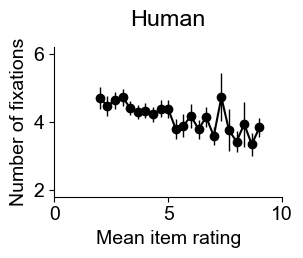

In [ ]:
plt.figure(figsize = (3.25, 2.8))
df_filtered = df
df_grouped = df_filtered.groupby(['pid', 'value_means'])['fixation_counts'].mean().reset_index()
df_summary = df_grouped.groupby(['value_means'])['fixation_counts'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['value_means'], df_summary['mean'], yerr = df_summary['se'], fmt = '-o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
# plt.xticks(range(2, 10, 2))
plt.xticks([0, 5, 10])
plt.ylim((1.8, 6.2))
plt.xlabel('Mean item rating')
plt.ylabel('Number of fixations')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_fixation_num_by_rating_mean.pdf', bbox_inches = 'tight')

## Fixation duration vs. fixation number (Fig 4C)

In [18]:
max_fixation_number = 7
durations = []

for pid, data_subj in enumerate(data):

    durations_subj = [[] for _ in range(max_fixation_number)]

    for i in range(len(data_subj['pids'])):
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        duration_seq_ep = data_subj['duration_seqs'][i]

        # append duration according to fixation number
        # if less than 7 fixations
        if len(fixation_seq_ep) <= max_fixation_number:
            # first 6 fixations
            for t in range(len(fixation_seq_ep) - 1):
                durations_subj[t].append(duration_seq_ep[t])

            # last fixation
            durations_subj[-1].append(duration_seq_ep[-1])

        # if more than 7 fixations
        elif len(fixation_seq_ep) > max_fixation_number:
            # fist 5 fixations
            for t in range(max_fixation_number - 2):
                durations_subj[t].append(duration_seq_ep[t])

            # middle fixaitons
            for t in range(max_fixation_number - 2, len(fixation_seq_ep) - 1):
                durations_subj[max_fixation_number - 2].append(duration_seq_ep[t])

            # last fixation
            durations_subj[-1].append(duration_seq_ep[-1])
    
    # get mean for each fixation number
    durations_subj = [np.mean(_) for _ in durations_subj]

    durations.append(durations_subj)

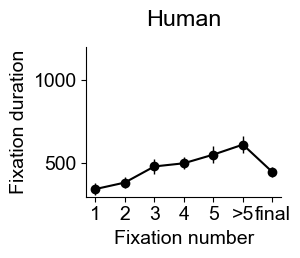

In [19]:
durations = np.array(durations)
means = np.nanmean(durations, axis = 0)
errors = np.nanstd(durations, axis = 0, ddof = 1) / np.sqrt(np.sum(~np.isnan(durations), axis = 0))

plt.figure(figsize = (3.2, 2.8))
plt.errorbar(np.arange(1, len(means) + 1), means, yerr = errors, color = 'k', fmt = 'o-', elinewidth = 1, capsize = 0)
labels = list(np.arange(1, len(means) + 1))
labels[-2] = '>5'
labels[-1] = 'final'
plt.xticks(ticks = np.arange(1, len(means) + 1), labels = labels)
plt.ylim(300, 1200)
plt.xlabel('Fixation number')
plt.ylabel('Fixation duration')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_fixation_length_by_fixation_index.pdf', bbox_inches = 'tight')

In [20]:
max_fixation_number = 7
durations = [[] for _ in range(max_fixation_number)]

for pid, data_subj in enumerate(data):

    durations_subj = [[] for _ in range(max_fixation_number)]

    for i in range(len(data_subj['pids'])):
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        duration_seq_ep = data_subj['duration_seqs'][i]

        if len(fixation_seq_ep) <= max_fixation_number:
            durations_subj[len(fixation_seq_ep) - 1].append(duration_seq_ep)
    
    durations_subj = [np.array(_).mean(axis = 0) for _ in durations_subj]

    for j in range(max_fixation_number):
        durations[j].append(durations_subj[j])

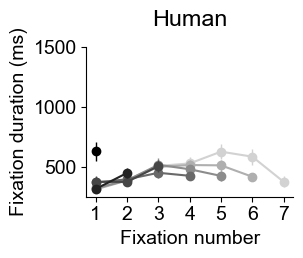

In [21]:
plt.figure(figsize = (3.25, 2.8))
colors = ['#000000', '#232323', '#464646', '#696969', '#8c8c8c', '#afafaf', '#d2d2d2']

for i in range(max_fixation_number):
    durations_len = np.vstack([
        x if isinstance(x, np.ndarray) else np.full(i + 1, np.nan)
        for x in durations[i]
    ])

    means = np.nanmean(durations_len, axis = 0)
    errors = np.nanstd(durations_len, axis = 0, ddof = 1) / np.sqrt(np.sum(~np.isnan(durations_len), axis = 0))

    plt.errorbar(np.arange(1, i + 2), means, yerr = errors, color = colors[i], fmt = 'o-', elinewidth = 1, capsize = 0, zorder = -i)

plt.xticks(ticks = np.arange(1, max_fixation_number + 1))
plt.ylim(250, 1500)
plt.xlabel('Fixation number')
plt.ylabel('Fixation duration (ms)')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_fixation_length_by_fixation_index.pdf', bbox_inches = 'tight')

## Distribution of fixation advantage (Fig 5A)

In [22]:
fixation_advantages = []

for pid, data_subj in enumerate(data):

    for i in range(len(data_subj['pids'])):
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        duration_seq_ep = data_subj['duration_seqs'][i]

        cum_durations_ep = np.zeros(3) # running sum of cumulative fixation lengths for both options

        for t, fixation in enumerate(fixation_seq_ep):
            if t >= 1: # exclude the first fixation
                index = int(fixation)
                fixation_advantages.append(cum_durations_ep[index] - np.mean(cum_durations_ep[np.arange(3) != index]))

            # update running sum
            index = int(fixation)
            cum_durations_ep[index] += duration_seq_ep[t]

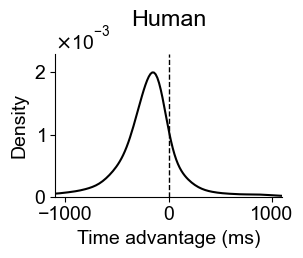

In [23]:
plt.figure(figsize = (3.4, 2.8))
sns.kdeplot(fixation_advantages, bw_adjust = 1, gridsize = 1000, color = 'black')
plt.axvline(x = 0, color = 'k', linestyle = '--', linewidth = 1)
plt.xlim(-1100, 1100)
plt.ylim(0, 0.0023)
plt.xlabel('Time advantage (ms)')
plt.ylabel('Density')
plt.title('Human', pad = 20)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
ax.ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0)) # force scientific notation
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_fixation_advantage.pdf', bbox_inches = 'tight')

Note: If the kernel estimation doesn't quantitatively match the network behavior, maybe histogram is a better choice.

## Proportion fixate left vs. left-right/left-other rating difference (Fig 6A)

In [24]:
dfs = []

for pid, data_subj in enumerate(data):

    value_differences_subj = []
    fixation_proportions_subj = []

    for i in range(len(data_subj['pids'])):
        values_ep = data_subj['values'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        duration_seq_ep = data_subj['duration_seqs'][i]

        fixation_seq_ep = np.array(fixation_seq_ep)
        duration_seq_ep = np.array(duration_seq_ep)
    
        value_differences_subj.append(values_ep[0] - np.mean(values_ep[1:]))
        indices = np.where(fixation_seq_ep == 0)[0]
        fixation_proportions_subj.append(duration_seq_ep[indices].sum() / duration_seq_ep.sum())
    
    df_subj = pd.DataFrame({
        'value_differences': value_differences_subj,
        'fixation_proportions': fixation_proportions_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

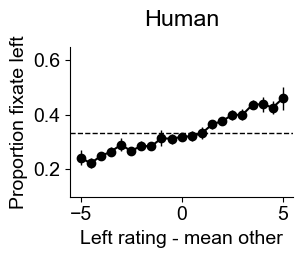

In [25]:
plt.figure(figsize = (3.25, 2.8))
df_filtered = df[(df['value_differences'] >= -5) & (df['value_differences'] <= 5)]
df_grouped = df_filtered.groupby(['pid', 'value_differences'])['fixation_proportions'].mean().reset_index()
df_summary = df_grouped.groupby(['value_differences'])['fixation_proportions'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['value_differences'], df_summary['mean'], yerr = df_summary['se'], fmt = '-o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
plt.axhline(y = 1 / 3, color = 'k', linestyle = '--', linewidth = 1)
plt.xticks([-5, 0, 5])
plt.ylim((0.1, 0.65))
plt.xlabel('Left rating - mean other')
plt.ylabel('Proportion fixate left')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_fixation_proportion_by_rating_difference.pdf', bbox_inches = 'tight')

## First fixation duration vs. first fixated item rating (Fig 6B)

In [26]:
dfs = []

for pid, data_subj in enumerate(data):

    first_fixation_values_subj = []
    first_fixation_durations_subj = []

    for i in range(len(data_subj['pids'])):
        values_ep = data_subj['values'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        durations_seq_ep = data_subj['duration_seqs'][i]

        index = int(fixation)
        first_fixation_values_subj.append(values_ep[index])
        first_fixation_durations_subj.append(durations_seq_ep[0])
    
    df_subj = pd.DataFrame({
        'first_fixation_values': first_fixation_values_subj,
        'first_fixation_durations': first_fixation_durations_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

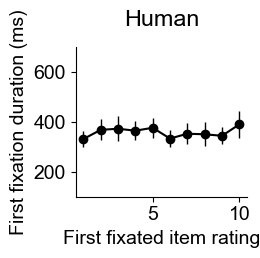

In [27]:
plt.figure(figsize = (2.8, 2.8))
df_grouped = df.groupby(['pid', 'first_fixation_values'])['first_fixation_durations'].mean().reset_index()
df_summary = df_grouped.groupby(['first_fixation_values'])['first_fixation_durations'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['first_fixation_values'], df_summary['mean'], yerr = df_summary['se'], fmt = '-o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
# plt.xticks([-5, 0, 5])
plt.ylim((100, 700))
plt.xlabel('First fixated item rating')
plt.ylabel('First fixation duration (ms)')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_first_fixation_duration_by_rating.pdf', bbox_inches = 'tight')

## Probability of fixating the worst vs. cumulative fixation time (Fig 6C)

In [28]:
bin = 100
max_duration = 1600
num_bins = int(max_duration / bin)

if_fixate_worsts = []

for pid, data_subj in enumerate(data):

    if_fixate_worsts_subj = [[] for _ in range(num_bins)]

    for i in range(len(data_subj['pids'])):
        values_ep = data_subj['values'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        duration_seq_ep = data_subj['duration_seqs'][i]

        # only when values are unique
        if len(np.unique(values_ep)) == 3:

            for t, time in enumerate(np.arange(100, max_duration, bin)):

                # get cumulative durations
                cum_duration_seq_ep = np.cumsum(duration_seq_ep)

                # find the fixation index
                current_fixation_number = np.searchsorted(cum_duration_seq_ep, time)

                # break if exceed maximum time
                if time > cum_duration_seq_ep[-1]:
                    break

                # get the fixated item
                current_fixation = fixation_seq_ep[current_fixation_number]

                # append if fixate worst
                index = int(current_fixation)
                if_fixate_worsts_subj[t].append(int(values_ep[index] == min(values_ep)))
        
    # get mean for each bin
    if_fixate_worsts_subj = [np.mean(_) for _ in if_fixate_worsts_subj]

    if_fixate_worsts.append(if_fixate_worsts_subj)

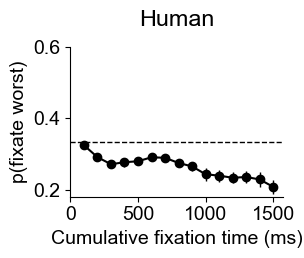

In [29]:
if_fixate_worsts = np.array(if_fixate_worsts)
means = np.nanmean(if_fixate_worsts, axis = 0)
errors = np.nanstd(if_fixate_worsts, axis = 0, ddof = 1) / np.sqrt(np.sum(~np.isnan(if_fixate_worsts), axis = 0))

plt.figure(figsize = (3.25, 2.8))
plt.errorbar(np.arange(1, len(means) + 1), means, yerr = errors, color = 'k', fmt = 'o-', elinewidth = 1, capsize = 0)
plt.axhline(y = 1 / 3, color = 'k', linestyle = '--', linewidth = 1)
plt.ylim((0.18, 0.6))
plt.xticks([0, 5, 10, 15], labels = [0, 500, 1000, 1500])
plt.xlabel('Cumulative fixation time (ms)')
plt.ylabel('p(fixate worst)')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_worst_fixation_proportion_by_cumulative_length.pdf', bbox_inches = 'tight')

## Choosing last fixated item vs. rating difference (Fig 7A)

In [31]:
dfs = []

for pid, data_subj in enumerate(data):

    value_differences_subj = []
    if_last_chosens_subj = []

    for i in range(len(data_subj['pids'])):
        values_ep = data_subj['values'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        decision_ep = data_subj['decisions'][i]

        values_ep = np.array(values_ep)

        final_fixation = fixation_seq_ep[-1]
        index = int(final_fixation)

        value_differences_subj.append(values_ep[index] - np.mean(values_ep[np.arange(3) != index]))
        if_last_chosens_subj.append(int(index == decision_ep))

    df_subj = pd.DataFrame({
        'value_differences': value_differences_subj,
        'if_last_chosens': if_last_chosens_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

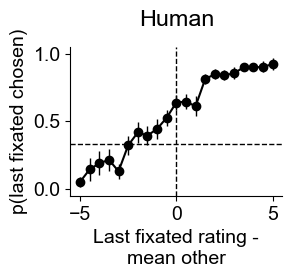

In [32]:
plt.figure(figsize = (3.25, 3))
df_filtered = df[(df['value_differences'] >= -5) & (df['value_differences'] <= 5)]
df_grouped = df_filtered.groupby(['pid', 'value_differences'])['if_last_chosens'].mean().reset_index()
df_summary = df_grouped.groupby(['value_differences'])['if_last_chosens'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['value_differences'], df_summary['mean'], yerr = df_summary['se'], fmt = '-o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
plt.axhline(y = 1 / 3, color = 'k', linestyle = '--', linewidth = 1)
plt.axvline(x = 0, color = 'k', linestyle = '--', linewidth = 1)
plt.xticks([-5, 0, 5])
plt.ylim((-0.05, 1.05))
plt.xlabel('Last fixated rating -\nmean other')
plt.ylabel('p(last fixated chosen)')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_last_fixation_chosen_by_rataing_difference.pdf', bbox_inches = 'tight')

## Choosing left vs. time advantage left (Fig 7B)

In [33]:
dfs = []

for pid, data_subj in enumerate(data):

    final_fixation_advantages_subj = []
    if_left_chosens_subj = []

    for i in range(len(data_subj['pids'])):
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        duration_seq_ep = data_subj['duration_seqs'][i]
        decision_ep = data_subj['decisions'][i]

        fixation_seq_ep = np.array(fixation_seq_ep)
        duration_seq_ep = np.array(duration_seq_ep)

        if len(fixation_seq_ep) > 1:

            left_indices = np.where(fixation_seq_ep == 0)[0]
            other1_indices = np.where(fixation_seq_ep == 1)[0]
            other2_indices = np.where(fixation_seq_ep == 2)[0]
            time_advantage = np.sum(duration_seq_ep[left_indices]) - np.mean([
                np.sum(duration_seq_ep[other1_indices]),
                np.sum(duration_seq_ep[other2_indices]),
            ])

            final_fixation_advantages_subj.append(time_advantage)
            if_left_chosens_subj.append(int(decision_ep == 0))

    df_subj = pd.DataFrame({
        'final_fixation_advantages': final_fixation_advantages_subj,
        'if_left_chosens': if_left_chosens_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

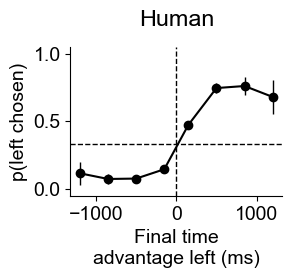

In [ ]:
plt.figure(figsize = (3.25, 3))
df_filtered = df
bins = [-1400, -1200, -800, -400, 0, 400, 800, 1200, 1400]
labels = [-1200, -850, -500, -150, 150, 500, 850, 1200]
df_filtered['group'] = pd.cut(df_filtered['final_fixation_advantages'], bins = bins, labels = labels, include_lowest = False, right = False)
df_grouped = df_filtered.groupby(['pid', 'group'])['if_left_chosens'].mean().reset_index()
df_summary = df_grouped.groupby(['group'])['if_left_chosens'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['group'], df_summary['mean'], yerr = df_summary['se'], fmt = '-o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
plt.axhline(y = 1 / 3, color = 'k', linestyle = '--', linewidth = 1)
plt.axvline(x = 0, color = 'k', linestyle = '--', linewidth = 1)
plt.ylim((-0.05, 1.05))
plt.xlabel('Final time\nadvantage left (ms)')
plt.ylabel('p(left chosen)')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_choice_by_fixation_advantage.pdf', bbox_inches = 'tight')

## Choosing first fixated vs. first fixated furation (Figure 7C)

In [35]:
dfs = []

for pid, data_subj in enumerate(data):

    first_fixation_durations_subj = []
    if_first_chosens_subj = []

    for i in range(len(data_subj['pids'])):
        values_ep = data_subj['values'][i]
        fixation_seq_ep = data_subj['fixation_seqs'][i]
        durations_seq_ep = data_subj['duration_seqs'][i]
        decision_ep = data_subj['decisions'][i]

        first_fixation = fixation_seq_ep[0]
        index = int(first_fixation)

        first_fixation_durations_subj.append(durations_seq_ep[0])
        if_first_chosens_subj.append(int(index == decision_ep))
    
    df_subj = pd.DataFrame({
        'first_fixation_durations': first_fixation_durations_subj,
        'if_first_chosens': if_first_chosens_subj,
    })
    df_subj['pid'] = pid
    dfs.append(df_subj)

df = pd.concat(dfs)

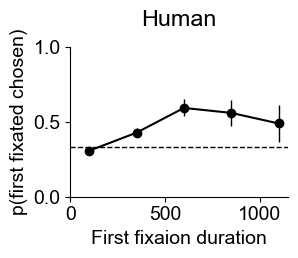

In [36]:
plt.figure(figsize = (3.2, 2.8))
df_filtered = df[df['first_fixation_durations'] <= 2000]
bins = [0, 250, 500, 750, 1000, 10000]
labels = [100, 350, 600, 850, 1100]
df_filtered['group'] = pd.cut(df_filtered['first_fixation_durations'], bins = bins, labels = labels, include_lowest = False, right = False)
df_grouped = df_filtered.groupby(['pid', 'group'])['if_first_chosens'].mean().reset_index()
df_summary = df_grouped.groupby(['group'])['if_first_chosens'].agg(['mean', 'std', 'count']).reset_index()
df_summary['se'] = df_summary['std'] / np.sqrt(df_summary['count'])
plt.errorbar(df_summary['group'], df_summary['mean'], yerr = df_summary['se'], fmt = '-o', color = 'black', ecolor = 'black', elinewidth = 1, capsize = 0)
plt.axhline(y = 1 / 3, color = 'k', linestyle = '--', linewidth = 1)
plt.xticks([0, 500, 1000])
plt.ylim((0, 1))
plt.xlabel('First fixaion duration')
plt.ylabel('p(first fixated chosen)')
plt.title('Human', pad = 15)
plt.tight_layout()
# plt.show()
plt.savefig('figures/figures_3arm/p_pcb_choice_by_first_fixation_duration.pdf', bbox_inches = 'tight')